# NB04 — Competitor Mini-Briefs

This notebook is the **Phase 5 competitor baseline** for the sandbox. It keeps the scope
small on purpose:

> use the existing three-cuisine restaurant/review corpus and the saved retrieval evidence
> to produce a handful of readable competitor mini-briefs that can feed the horizon scan
> and later menu-generation thinking, without expanding into a full agent system.

This notebook does **not** implement graph retrieval, multi-agent orchestration, or an
automated menu generator. It produces a text-first intelligence layer only.

Main outputs:

- `data/processed/competitor_minibriefs.csv`
- `data/processed/competitor_retrieval_demo.csv`
- `outputs/figures/nb04/fig30_nb04_minibrief_heatmap.png`
- `outputs/figures/nb04/fig31_nb04_retrieval_demo.png`

The intended deliverable is a small table of `5-10` mini-briefs, not a large pipeline.

## 1. Environment setup

The notebook reuses the same three-cuisine evidence base already established in `NB02e`.
That means:

- Italian remains the anchor cuisine
- American (New) remains the main contemporary comparison
- Mexican remains a useful text-side benchmark where review patterns help contextualise
  the landscape

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.sentiment import SentimentIntensityAnalyzer

ROOT = Path().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
assert (ROOT / "configs").exists(), f"Cannot find project root from {Path().resolve()}"

PROCESSED = ROOT / "data" / "processed"
NB02E_DIR = ROOT / "outputs" / "figures" / "nb02e"
FIG_DIR = ROOT / "outputs" / "figures" / "nb04"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MINIBRIEF_CSV = PROCESSED / "competitor_minibriefs.csv"
RETRIEVAL_DEMO_CSV = PROCESSED / "competitor_retrieval_demo.csv"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 150, "savefig.bbox": "tight"})

print(f"Project root       : {ROOT}")
print(f"Processed dir      : {PROCESSED}")
print(f"NB02e figures dir  : {NB02E_DIR}")
print(f"NB04 figures dir   : {FIG_DIR}")
print(f"Mini-brief output  : {MINIBRIEF_CSV}")
print(f"Retrieval demo out : {RETRIEVAL_DEMO_CSV}")

Project root       : /home/endy/menuforge
Processed dir      : /home/endy/menuforge/data/processed
NB02e figures dir  : /home/endy/menuforge/outputs/figures/nb02e
NB04 figures dir   : /home/endy/menuforge/outputs/figures/nb04
Mini-brief output  : /home/endy/menuforge/data/processed/competitor_minibriefs.csv
Retrieval demo out : /home/endy/menuforge/data/processed/competitor_retrieval_demo.csv


## 2. Rebuild the unified three-cuisine frames

This mirrors the three-way merge used in `NB02e`. The difference is that `NB04` does not
run a fresh retrieval benchmark. Instead, it consumes the corpus for compact intelligence
summaries.

In [2]:
italian_rest = pd.read_parquet(PROCESSED / "restaurants.parquet").copy()
italian_rest["cuisine_type"] = "italian"

comparison_rest = pd.read_parquet(PROCESSED / "comparison_restaurants.parquet").copy()

italian_rev = pd.read_parquet(PROCESSED / "reviews.parquet").copy()
italian_rev["cuisine_type"] = "italian"

comparison_rev = pd.read_parquet(PROCESSED / "comparison_reviews.parquet").copy()

rest_cols = sorted(set(italian_rest.columns).union(comparison_rest.columns))
rev_cols = sorted(set(italian_rev.columns).union(comparison_rev.columns))

restaurants_all = pd.concat(
    [italian_rest.reindex(columns=rest_cols), comparison_rest.reindex(columns=rest_cols)],
    ignore_index=True,
)
reviews_all = pd.concat(
    [italian_rev.reindex(columns=rev_cols), comparison_rev.reindex(columns=rev_cols)],
    ignore_index=True,
)

restaurants_all["price"] = pd.to_numeric(restaurants_all["price_range"], errors="coerce")
reviews_all["date"] = pd.to_datetime(reviews_all["date"], errors="coerce")

CUISINE_ORDER = ["italian", "american_new", "mexican"]
CUISINE_LABELS = {
    "italian": "Italian",
    "american_new": "American (New)",
    "mexican": "Mexican",
}
CITY_ORDER = ["Philadelphia", "Tampa"]

print("Restaurants by cuisine:")
print(restaurants_all["cuisine_type"].value_counts().reindex(CUISINE_ORDER).to_string())
print()
print("Reviews by cuisine:")
print(reviews_all["cuisine_type"].value_counts().reindex(CUISINE_ORDER).to_string())
print()
print("Rows by cuisine and city:")
print(restaurants_all.groupby(["cuisine_type", "city"]).size().to_string())

Restaurants by cuisine:
cuisine_type
italian          717
american_new    1099
mexican          522

Reviews by cuisine:
cuisine_type
italian         105774
american_new    113265
mexican          39201

Rows by cuisine and city:
cuisine_type  city        
american_new  Philadelphia    751
              Tampa           348
italian       Philadelphia    505
              Tampa           212
mexican       Philadelphia    302
              Tampa           220


## 3. Load the saved retrieval audit from NB02e

Phase 5 should stay small. Rather than rerunning LanceDB queries, this notebook reuses the
saved top-5 retrieval audit table from `NB02e` and turns it into a compact “is hybrid
sufficient for this reduced baseline?” summary.

In [3]:
retrieval_audit = pd.read_csv(NB02E_DIR / "retrieval_audit_table.csv")

retrieval_summary = (
    retrieval_audit.groupby(["query_text", "query_family", "mode"], as_index=False)["alignment"]
    .mean()
    .rename(columns={"alignment": "alignment_at_5"})
)

mode_summary = (
    retrieval_summary.groupby(["query_family", "mode"], as_index=False)["alignment_at_5"]
    .mean()
    .sort_values(["query_family", "alignment_at_5"], ascending=[True, False])
)

print(mode_summary.to_string(index=False))


query_family   mode  alignment_at_5
       mixed hybrid        0.650000
       mixed vector        0.616667
       mixed    fts        0.600000
named_entity    fts        0.825000
named_entity hybrid        0.541667
named_entity vector        0.491667
    semantic vector        1.000000
    semantic hybrid        0.933333
    semantic    fts        0.800000


## 4. Build lightweight theme extractors

The mini-briefs need two text-side theme fields:

- `praised themes` from 5-star reviews
- `complaint themes` from 1-star reviews

This stays intentionally simple. It is a descriptive baseline, not a domain-tuned topic
model.

In [4]:
def top_bigrams(texts, n=5, min_df=3):
    texts = [str(t).strip() for t in texts if str(t).strip()]
    if len(texts) < max(min_df, 5):
        return []

    vec = TfidfVectorizer(
        ngram_range=(2, 2),
        stop_words="english",
        max_features=5000,
        min_df=min_df,
        strip_accents="unicode",
    )
    X = vec.fit_transform(texts)
    scores = np.asarray(X.mean(axis=0)).flatten()
    terms = vec.get_feature_names_out()
    idx = scores.argsort()[::-1][:n]
    return [terms[i] for i in idx]


def dominant_price_tier(series: pd.Series) -> str:
    vals = series.dropna()
    if vals.empty:
        return "unknown"
    tier = int(vals.mode().iloc[0])
    return {1: "$", 2: "$$", 3: "$$$", 4: "$$$$"}.get(tier, "unknown")


def rating_band(series: pd.Series) -> str:
    median = float(series.median())
    if median >= 4.5:
        return "very strong"
    if median >= 4.0:
        return "strong"
    if median >= 3.5:
        return "mid-tier"
    return "weaker / mixed"


def representative_competitors(df: pd.DataFrame, n=3) -> list[str]:
    cols = ["name", "stars", "review_count"]
    ranked = (
        df[cols]
        .dropna(subset=["name"])
        .sort_values(["review_count", "stars"], ascending=[False, False])
        .drop_duplicates("name")
        .head(n)
    )
    return [
        f"{row['name']} ({row['stars']:.1f}★, {int(row['review_count'])} reviews)"
        for _, row in ranked.iterrows()
    ]


sia = SentimentIntensityAnalyzer()
reviews_all["vader"] = reviews_all["text"].fillna("").map(lambda t: sia.polarity_scores(t)["compound"])
print("VADER scored for NB04 mini-brief use.")

VADER scored for NB04 mini-brief use.


## 5. Define the mini-brief slices

The brief set is deliberately small and readable:

- 2 Italian anchor slices
- 2 American (New) contemporary comparison slices
- 2 Mexican text-side comparison slices

That gives six mini-briefs, which is enough to satisfy the plan without bloating the
sandbox.

In [5]:
brief_specs = [
    {"cuisine_type": "italian", "city": "Philadelphia"},
    {"cuisine_type": "italian", "city": "Tampa"},
    {"cuisine_type": "american_new", "city": "Philadelphia"},
    {"cuisine_type": "american_new", "city": "Tampa"},
    {"cuisine_type": "mexican", "city": "Philadelphia"},
    {"cuisine_type": "mexican", "city": "Tampa"},
]

brief_df = pd.DataFrame(brief_specs)
display(brief_df)

,cuisine_type,city
0,italian,Philadelphia
1,italian,Tampa
2,american_new,Philadelphia
3,american_new,Tampa
4,mexican,Philadelphia
5,mexican,Tampa


## 6. Create the competitor mini-briefs

Each mini-brief records:

- cuisine and city
- rating band
- dominant price tier
- praised themes
- complaint themes
- representative competitors
- a short bridging note explaining how the slice could later inform menu-generation or
  concept-design work

The bridging note is future-facing, but the evidence underneath it is current and local.

In [6]:
def build_bridging_note(cuisine_label: str, city: str, price_tier: str, praised: list[str], complaints: list[str]) -> str:
    praise_text = ", ".join(praised[:2]) if praised else "stronger positive review signals"
    complaint_text = ", ".join(complaints[:2]) if complaints else "service and execution complaints"
    return (
        f"For a later menu or concept-design workflow, this slice suggests a {price_tier} "
        f"{cuisine_label} baseline in {city} should preserve strengths around {praise_text} "
        f"while avoiding recurring complaint patterns such as {complaint_text}."
    )


records = []

for spec in brief_specs:
    cuisine = spec["cuisine_type"]
    city = spec["city"]
    cuisine_label = CUISINE_LABELS[cuisine]

    rest_slice = restaurants_all[
        (restaurants_all["cuisine_type"] == cuisine) & (restaurants_all["city"] == city)
    ].copy()
    rev_slice = reviews_all[
        (reviews_all["cuisine_type"] == cuisine) & (reviews_all["city"] == city)
    ].copy()

    top_names = representative_competitors(rest_slice, n=3)
    praised = top_bigrams(rev_slice.loc[rev_slice["stars"] == 5.0, "text"].fillna("").tolist(), n=5, min_df=3)
    complaints = top_bigrams(rev_slice.loc[rev_slice["stars"] == 1.0, "text"].fillna("").tolist(), n=5, min_df=3)

    median_stars = float(rest_slice["stars"].median())
    mean_vader = float(rev_slice["vader"].mean())
    median_review_count = float(rest_slice["review_count"].median())
    price_tier = dominant_price_tier(rest_slice["price"])
    band = rating_band(rest_slice["stars"])

    record = {
        "cuisine": cuisine_label,
        "cuisine_type": cuisine,
        "city": city,
        "restaurants_n": int(len(rest_slice)),
        "reviews_n": int(len(rev_slice)),
        "median_stars": round(median_stars, 2),
        "rating_band": band,
        "dominant_price_tier": price_tier,
        "median_review_count": int(round(median_review_count)),
        "mean_vader": round(mean_vader, 3),
        "praised_themes": " | ".join(praised[:3]),
        "complaint_themes": " | ".join(complaints[:3]),
        "representative_competitors": " | ".join(top_names),
        "bridging_note": build_bridging_note(cuisine_label, city, price_tier, praised, complaints),
    }
    records.append(record)

minibriefs = pd.DataFrame(records)
minibriefs.to_csv(MINIBRIEF_CSV, index=False)

display(minibriefs)
print(f"Saved: {MINIBRIEF_CSV}")

,cuisine,cuisine_type,city,restaurants_n,reviews_n,median_stars,rating_band,dominant_price_tier,median_review_count,mean_vader,praised_themes,complaint_themes,representative_competitors,bridging_note
0,Italian,italian,Philadelphia,505,82982,3.5,mid-tier,$$,65,0.709,highly recommend | great food | best pizza,customer service | tasted like | cheese steak,"Pat's King of Steaks (3.0★, 4250 reviews) | Ba...","For a later menu or concept-design workflow, t..."
1,Italian,italian,Tampa,212,22792,4.0,strong,$$,41,0.684,highly recommend | great food | italian food,customer service | food good | pizza hut,"Maggiano's Little Italy (4.0★, 586 reviews) | ...","For a later menu or concept-design workflow, t..."
2,American (New),american_new,Philadelphia,751,78975,3.5,mid-tier,$$,87,0.699,highly recommend | great food | happy hour,customer service | tasted like | 20 minutes,"Parc (4.0★, 2761 reviews) | Green Eggs Café (4...","For a later menu or concept-design workflow, t..."
3,American (New),american_new,Tampa,348,34290,3.5,mid-tier,$$,76,0.682,great food | highly recommend | great service,customer service | tasted like | 20 minutes,"Datz (4.0★, 3260 reviews) | Ulele (4.0★, 3064 ...","For a later menu or concept-design workflow, t..."
4,Mexican,mexican,Philadelphia,302,23271,4.0,strong,$,44,0.655,mexican food | highly recommend | al pastor,mexican food | taco bell | customer service,"El Vez (4.0★, 3187 reviews) | Distrito (3.5★, ...","For a later menu or concept-design workflow, t..."
5,Mexican,mexican,Tampa,220,15930,4.0,strong,$,38,0.583,mexican food | great food | authentic mexican,taco bell | customer service | mexican food,"Lolis Mexican Cravings (4.5★, 1449 reviews) | ...","For a later menu or concept-design workflow, t..."


Saved: /home/endy/menuforge/data/processed/competitor_minibriefs.csv


## 7. Build the reduced retrieval demo

The competitor layer only needs to show that hybrid retrieval is **sufficient enough** for
small intelligence lookups. This cell selects a few grounded example queries from the
saved `NB02e` audit and compares the mode-level alignment scores side by side.

In [7]:
demo_queries = [
    "Barbuzzo Italian Philadelphia",
    "Datz American (New) Tampa",
    "El Vez Mexican Philadelphia",
    "Italian restaurants Tampa",
    "American New restaurants Philadelphia",
    "Mexican restaurants Tampa",
]

retrieval_demo = (
    retrieval_summary[retrieval_summary["query_text"].isin(demo_queries)]
    .sort_values(["query_text", "mode"])
    .reset_index(drop=True)
)

retrieval_demo.to_csv(RETRIEVAL_DEMO_CSV, index=False)

display(retrieval_demo)
print(f"Saved: {RETRIEVAL_DEMO_CSV}")
print()
print("Interpretive rule:")
print("For Phase 5, hybrid only needs to look sufficient for compact competitor lookups; it does not need to solve every named-entity edge case better than FTS.")

,query_text,query_family,mode,alignment_at_5
0,American New restaurants Philadelphia,semantic,fts,0.90
1,American New restaurants Philadelphia,semantic,hybrid,1.00
2,American New restaurants Philadelphia,semantic,vector,1.00
3,Barbuzzo Italian Philadelphia,mixed,fts,0.55
4,Barbuzzo Italian Philadelphia,mixed,hybrid,0.60
5,Barbuzzo Italian Philadelphia,mixed,vector,0.60
6,Datz American (New) Tampa,mixed,fts,0.45
7,Datz American (New) Tampa,mixed,hybrid,0.60
8,Datz American (New) Tampa,mixed,vector,0.50
9,El Vez Mexican Philadelphia,mixed,fts,0.55


Saved: /home/endy/menuforge/data/processed/competitor_retrieval_demo.csv

Interpretive rule:
For Phase 5, hybrid only needs to look sufficient for compact competitor lookups; it does not need to solve every named-entity edge case better than FTS.


## 8. Final summary card

This closes Phase 5 at the intended sandbox scale: readable mini-briefs, one small
retrieval sufficiency check, and no expansion into a larger agent build.

In [8]:
print("=" * 72)
print("NB04 SUMMARY — Minimal competitor baseline")
print("=" * 72)

print("\nMini-brief count:")
print(len(minibriefs))

print("\nBriefs by cuisine:")
print(minibriefs["cuisine"].value_counts().to_string())

print("\nRepresentative slices:")
display(
    minibriefs[
        [
            "cuisine",
            "city",
            "rating_band",
            "dominant_price_tier",
            "praised_themes",
            "complaint_themes",
        ]
    ]
)

print("\nRetrieval demo mean alignment by mode:")
print(retrieval_demo.groupby("mode")["alignment_at_5"].mean().round(3).to_string())

print("\nScope guardrail:")
print("This is a first-stage intelligence layer only. It does not implement graph retrieval, agents, or menu generation.")

print("\nNext:")
print("Phase 6 writeup integration and final sandbox endpoint consolidation.")

NB04 SUMMARY — Minimal competitor baseline

Mini-brief count:
6

Briefs by cuisine:
cuisine
Italian           2
American (New)    2
Mexican           2

Representative slices:


,cuisine,city,rating_band,dominant_price_tier,praised_themes,complaint_themes
0,Italian,Philadelphia,mid-tier,$$,highly recommend | great food | best pizza,customer service | tasted like | cheese steak
1,Italian,Tampa,strong,$$,highly recommend | great food | italian food,customer service | food good | pizza hut
2,American (New),Philadelphia,mid-tier,$$,highly recommend | great food | happy hour,customer service | tasted like | 20 minutes
3,American (New),Tampa,mid-tier,$$,great food | highly recommend | great service,customer service | tasted like | 20 minutes
4,Mexican,Philadelphia,strong,$,mexican food | highly recommend | al pastor,mexican food | taco bell | customer service
5,Mexican,Tampa,strong,$,mexican food | great food | authentic mexican,taco bell | customer service | mexican food



Retrieval demo mean alignment by mode:
mode
fts       0.692
hybrid    0.767
vector    0.767

Scope guardrail:
This is a first-stage intelligence layer only. It does not implement graph retrieval, agents, or menu generation.

Next:
Phase 6 writeup integration and final sandbox endpoint consolidation.


## 9. Compact Phase 5 visuals

These two figures are intentionally small and supportive:

- a heatmap that compares the six mini-brief slices on a few key competitive signals
- a grouped bar chart that shows whether the reduced retrieval demo looks sufficient for
  this text-first competitor baseline

They are not meant to replace the fuller `NB02e` evidence. They simply make `NB04` easier
to read at a glance.

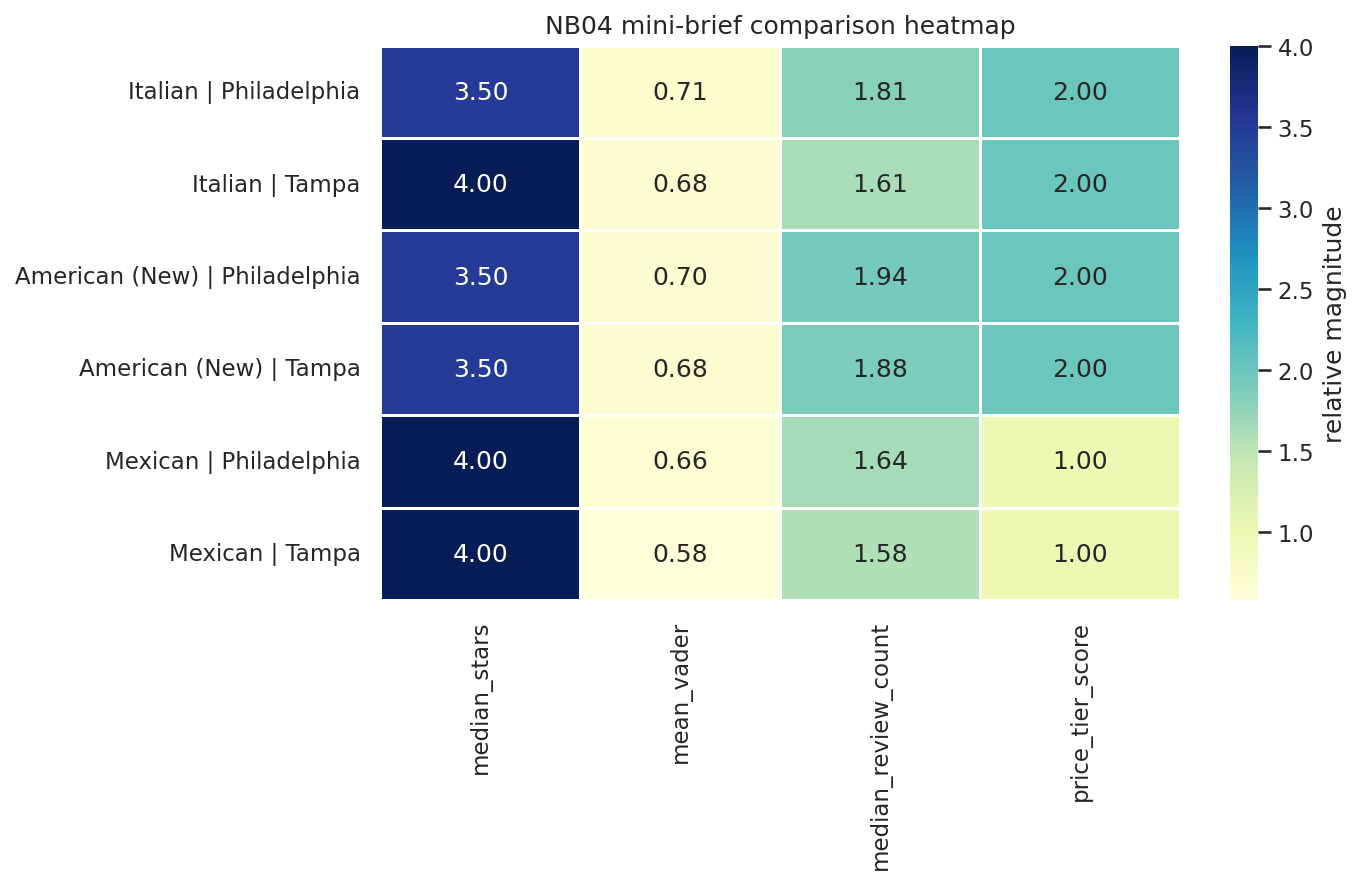

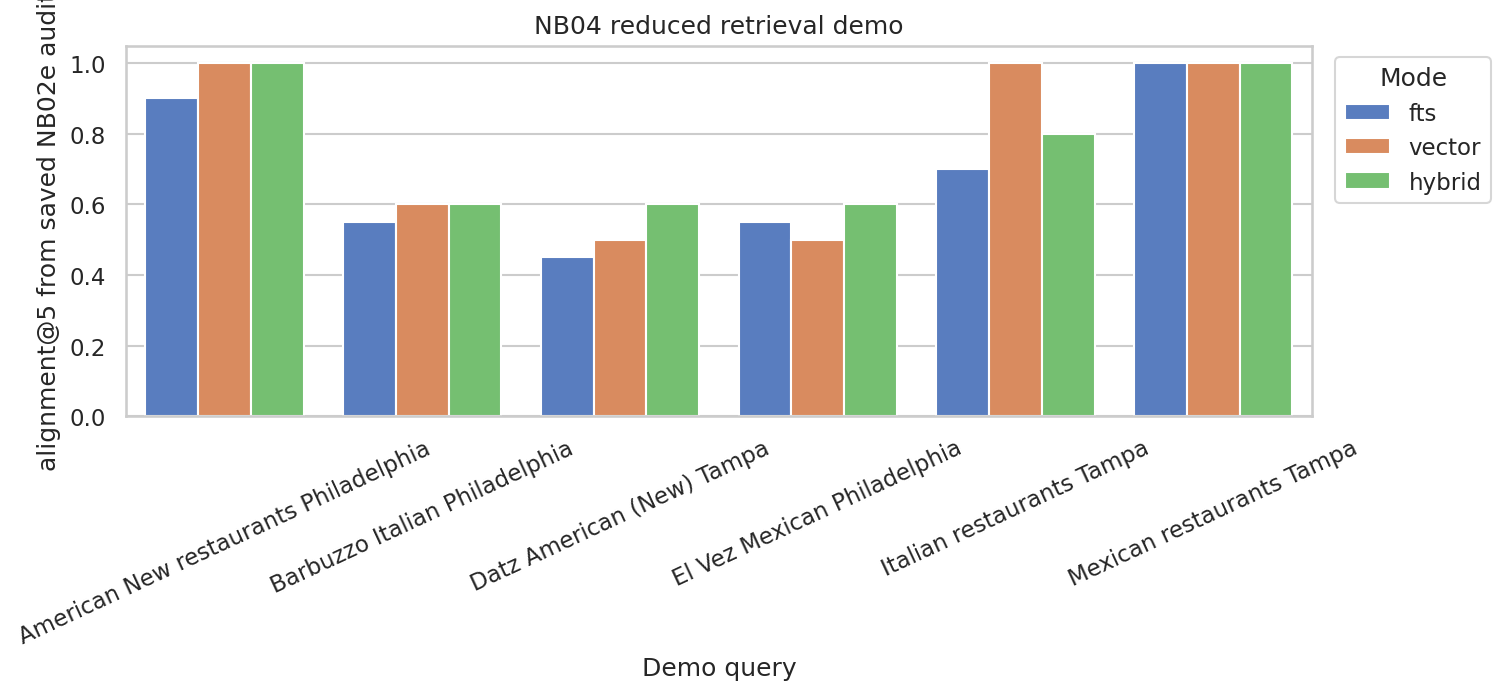

Saved figure: /home/endy/menuforge/outputs/figures/nb04/fig30_nb04_minibrief_heatmap.png
Saved figure: /home/endy/menuforge/outputs/figures/nb04/fig31_nb04_retrieval_demo.png


In [9]:
heatmap_df = minibriefs.copy()
heatmap_df["slice_label"] = heatmap_df["cuisine"] + " | " + heatmap_df["city"]
heatmap_df["price_tier_score"] = heatmap_df["dominant_price_tier"].map({
    "$": 1,
    "$$": 2,
    "$$$": 3,
    "$$$$": 4,
    "unknown": np.nan,
})

heatmap_plot = (
    heatmap_df[
        [
            "slice_label",
            "median_stars",
            "mean_vader",
            "median_review_count",
            "price_tier_score",
        ]
    ]
    .set_index("slice_label")
    .copy()
)

heatmap_plot["median_review_count"] = np.log10(heatmap_plot["median_review_count"].clip(lower=1))

fig, ax = plt.subplots(figsize=(8.6, 4.8))
sns.heatmap(
    heatmap_plot,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "relative magnitude"},
    ax=ax,
)
ax.set_title("NB04 mini-brief comparison heatmap")
ax.set_xlabel("")
ax.set_ylabel("")

fig30 = FIG_DIR / "fig30_nb04_minibrief_heatmap.png"
fig.savefig(fig30)
plt.show()

retrieval_plot = retrieval_demo.copy()
query_order = list(dict.fromkeys(retrieval_plot["query_text"].tolist()))
mode_order = ["fts", "vector", "hybrid"]

fig, ax = plt.subplots(figsize=(10.2, 4.8))
sns.barplot(
    data=retrieval_plot,
    x="query_text",
    y="alignment_at_5",
    hue="mode",
    order=query_order,
    hue_order=mode_order,
    ax=ax,
)
ax.set_title("NB04 reduced retrieval demo")
ax.set_xlabel("Demo query")
ax.set_ylabel("alignment@5 from saved NB02e audit")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Mode", bbox_to_anchor=(1.01, 1), loc="upper left")

fig.tight_layout()
fig31 = FIG_DIR / "fig31_nb04_retrieval_demo.png"
fig.savefig(fig31)
plt.show()

print(f"Saved figure: {fig30}")
print(f"Saved figure: {fig31}")